In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmap

import spikeinterface.core as si
import spikeinterface.extractors as se

probe_path          = Path(r"E:\pipeline_output\aa005\ProbeB")
concat_path         = probe_path / 'concat'
ks_output           = probe_path / 'kilosort'
fs = 30000.0

## Load probe channel information 
ch_pos              = np.load(ks_output / 'channel_positions.npy')
ch_shanks           = np.load(ks_output / 'channel_shanks.npy').astype(int)
contacts_df = pd.DataFrame(ch_pos, columns=['x', 'y'])
contacts_df['shank'] = ch_shanks.astype(int)


## Load detected spike positions and good units
unit_labels         = pd.read_csv(ks_output / 'cluster_group.tsv', sep='\t', index_col=0)
good_units          = unit_labels[unit_labels['KSLabel'] == 'good'].index.values
clu                 = np.load(ks_output / 'spike_clusters.npy', mmap_mode='r')
spike_locations     = np.load(ks_output / 'spike_positions.npy', mmap_mode='r')

good_mask = np.isin(clu, good_units)
spikes_df = pd.DataFrame(spike_locations[good_mask], columns=['x', 'y'])
spikes_df['cluster'] = clu[good_mask]
units_df = spikes_df.groupby('cluster').agg(['median', 'min', 'max'])
units_df.columns = ['_'.join(col) for col in units_df.columns]

## Color scheme
plt.style.use('dark_background')
heatmap = cmap.Colormap('seaborn:vlag').to_matplotlib()
distinct_colors = cmap.Colormap('tab20').to_matplotlib()

In [2]:
proccessing_folder = probe_path / 'postprocess'
# if proccessing_folder.exists():
#     pp = si.load_sorting_analyzer(proccessing_folder)
# else:    
## Load recording and sorting objects
rec = si.load(str(concat_path))
sorting = se.read_kilosort(ks_output).select_units(good_units)

pp = si.create_sorting_analyzer(
    sorting=sorting,
    recording=rec,
    sparse=False,
    folder=probe_path / 'postprocess',
    format='binary_folder',
    overwrite=True
)

job_kwargs = dict(n_jobs=-1, chunk_duration="1s", progress_bar=True)

compute_dict = {
    'random_spikes': {'method': 'uniform', 'max_spikes_per_unit': 10000},
    'templates': {'operators': ["average", "std"]},
    'waveforms': {},
}

pp.compute(compute_dict, **job_kwargs)

# # Compute waveforms extension if not already present (e.g. loaded from disk)
# if pp.get_extension('waveforms') is None:
#     job_kwargs = dict(n_jobs=-1, chunk_duration="1s", progress_bar=True)
#     pp.compute('waveforms', **job_kwargs)

c:\Users\iii9781\pipeline\.venv\Lib\site-packages\spikeinterface\core\base.py:1142: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.103.2 is recommended
  warnings.warn(


compute_waveforms (workers: 48 processes spawn):   0%|          | 0/16597 [00:00<?, ?it/s]

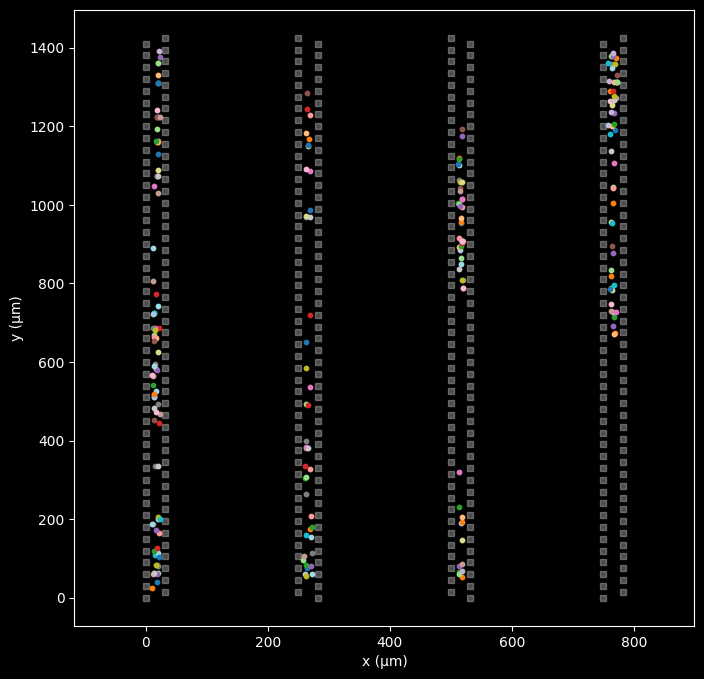

In [3]:
def plot_unit_positions(units_df, ch_pos, probe_path=None):
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(ch_pos[:, 0], ch_pos[:, 1], s=25, color='white', marker='s', alpha=0.3)

    for cluster_id, unit in units_df.iterrows():
        ax.scatter(unit['x_median'], unit['y_median'], s=10, color=distinct_colors(cluster_id % 20), marker='o')

    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    ax.set_xmargin(0.15)
    
    if probe_path is not None:    
        ax.set_title(f'{probe_path.name}: Unit Positions')
        fig.savefig(probe_path / 'unit_positions.png', dpi=320)
        plt.close(fig)
    else:
        return fig, ax

_ = plot_unit_positions(units_df, ch_pos)

In [4]:
index = 255
template_ext = pp.get_extension('templates')
unit_template = template_ext.get_unit_template(index, operator='average')

# Centering template to zero
for ch_id in range(unit_template.shape[1]):
    unit_template[:, ch_id] = unit_template[:, ch_id] - unit_template[:, ch_id].mean()    

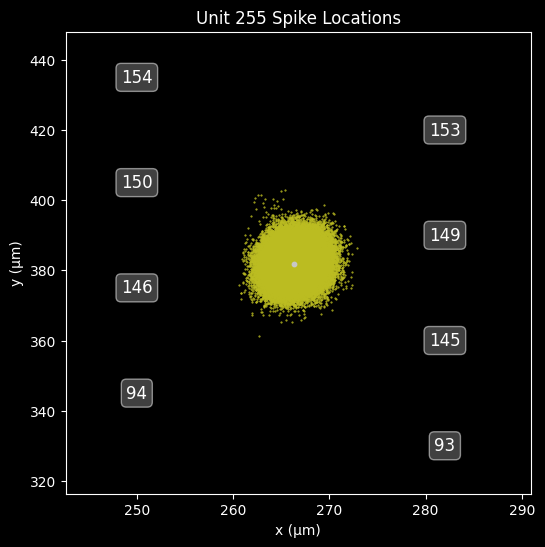

In [5]:
## Unit/Spikes location
def plot_unit_spikes(unit_index,
                     unit,
                     spikes,
                     contacts_df,
                     unit_path=None,
                     x_margin=18, y_margin=45):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(spikes['x'], spikes['y'], s=1, color=distinct_colors((unit_index + 1) % 20), marker='.')
    ax.scatter(unit['x_median'], unit['y_median'], s=10, color=distinct_colors(unit_index % 20), marker='o')

    x_mask = (contacts_df['x'] > (unit['x_min'] - x_margin)) & (contacts_df['x'] < (unit['x_max'] + x_margin))
    y_mask = (contacts_df['y'] > (unit['y_min'] - y_margin)) & (contacts_df['y'] < (unit['y_max'] + y_margin))
    for contact_id, contact in contacts_df[x_mask & y_mask].iterrows():
        ax.annotate(str(contact_id),
                    xy=(contact['x'], contact['y']),
                    fontsize=12, ha='center', va='center',
                    color='white', alpha=1,
                    bbox=dict(boxstyle='round,pad=0.3', fc='gray', alpha=0.5)
                    )

    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    ax.set_xlim(unit['x_min'] - x_margin, unit['x_max'] + x_margin)
    ax.set_ylim(unit['y_min'] - y_margin, unit['y_max'] + y_margin)
    ax.set_title(f'Unit {cluster_id} Spike Locations')
    if unit_path is not None:
        fig.savefig(unit_path / f'unit_{cluster_id}_spikes.png', dpi=320)
        plt.close(fig)
    else:
        return fig, ax

unit_index = 104
unit = units_df.iloc[unit_index]
cluster_id = unit.name
spikes = spikes_df[spikes_df['cluster'] == cluster_id]

_ = plot_unit_spikes(cluster_id, unit, spikes, contacts_df)

In [6]:
ms_before = pp.get_extension('templates').params['ms_before']
ms_after = pp.get_extension('templates').params['ms_after']
time_ms = np.arange(0-ms_before, ms_after, 1000/fs)

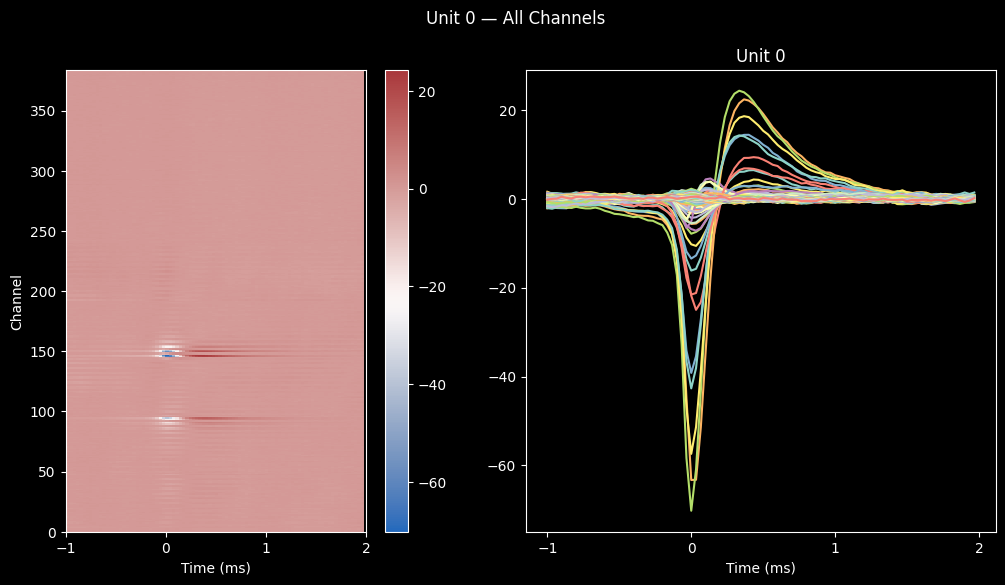

In [29]:
def plot_unit_template(unit_index, unit_template, unit_path=None):    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1.25]})
    fig.suptitle(f'Unit {unit_index} — All Channels')

    ## All channels Heatmap
    im = axes[0].imshow(unit_template.T,
                    aspect='auto', cmap=heatmap,
                    origin='lower', interpolation='none',
                    extent=[time_ms[0], time_ms[-1], 0, unit_template.shape[1]]
                    )

    axes[0].set_xlabel('Time (ms)')
    axes[0].set_xticks(np.linspace(-ms_before, ms_after, 4))
    axes[0].set_ylabel('Channel')

    fig.colorbar(im, ax=axes[0])

    ## All channels line plot
    for ch_id in range(unit_template.shape[1]):
        axes[1].plot(time_ms, unit_template[:, ch_id])

    axes[1].set_xlabel('Time (ms)')
    axes[1].set_xticks(np.linspace(-ms_before, ms_after, 4))
    axes[1].set_title(f'Unit {unit_index}')

    if unit_path is not None:
        fig.savefig(unit_path / f'unit_{unit_index}_template.png', dpi=320)
        plt.close(fig)
    else:
        return fig, axes

_ = plot_unit_template(0, unit_template)

Shank 0 channels (unsorted): [  0   3   4   7   8  11  12  15  16  19  20  23  24  27  28  31  32  35
  36  39  40  43  44  47  96  99 100 103 104 107 108 111 112 115 116 119
 120 123 124 127 128 131 132 135 136 139 140 143 192 195 196 199 200 203
 204 207 208 211 212 215 216 219 220 223 224 227 228 231 232 235 236 239
 288 291 292 295 296 299 300 303 304 307 308 311 312 315 316 319 320 323
 324 327 328 331 332 335]
Shank 0 channels (depth-sorted): [  0   3   4   7   8  11  12  15  16  19  20  23  24  27  28  31  32  35
  36  39  40  43  44  47  96  99 100 103 104 107 108 111 112 115 116 119
 120 123 124 127 128 131 132 135 136 139 140 143 192 195 196 199 200 203
 204 207 208 211 212 215 216 219 220 223 224 227 228 231 232 235 236 239
 288 291 292 295 296 299 300 303 304 307 308 311 312 315 316 319 320 323
 324 327 328 331 332 335]
Shank 1 channels (unsorted): [ 49  50  53  54  57  58  61  62  65  66  69  70  73  74  77  78  81  82
  85  86  89  90  93  94 145 146 149 150 153 154 157 1

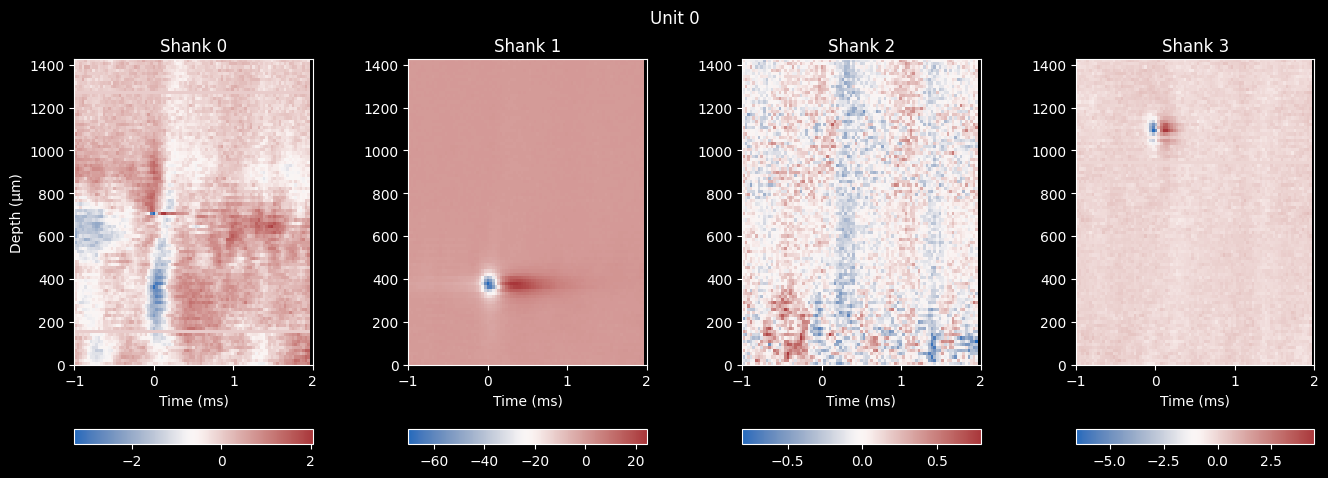

In [7]:
def plot_template_shanks(unit_index, unit_template, ch_shanks, ch_pos, unit_path=None):
    shanks = np.unique(ch_shanks)

    fig, axes = plt.subplots(2, len(shanks),
                        figsize=(16, 5),
                        sharex=False, sharey=False,
                        gridspec_kw={'height_ratios': [1, 0.05], 'wspace': 0.4, 'hspace': 0.4}
                        )
    
    # Derive y-tick step and range from all channel depths
    all_depths = ch_pos[:, 1]
    depth_step = 200
    tick_start = int(np.ceil(all_depths.min() / depth_step) * depth_step)
    tick_end = int(np.floor(all_depths.max() / depth_step) * depth_step)
    depth_ticks = np.arange(tick_start, tick_end + 1, depth_step)

    fig.suptitle(f'Unit {unit_index}')
    for shank_id in shanks:
        mask = ch_shanks == shank_id
        ch_indices = mask.nonzero()[0]
        print(f"Shank {shank_id} channels (unsorted): {ch_indices}")
        # Depth-sort channels
        depth_order = np.argsort(ch_pos[ch_indices, 1])
        sorted_indices = ch_indices[depth_order]
        print(f"Shank {shank_id} channels (depth-sorted): {sorted_indices}")
        depths = ch_pos[sorted_indices, 1]
        
        # Template heatmap
        im = axes[0, shank_id].imshow(unit_template[:, sorted_indices].T, 
                            aspect='auto', cmap=heatmap,
                            origin='lower', interpolation='none',
                            extent=[time_ms[0], time_ms[-1], depths[0], depths[-1]]
                            )
        
        # X ticks
        axes[0, shank_id].set_xlabel('Time (ms)')
        axes[0, shank_id].set_xticks(np.linspace(-ms_before, ms_after, 4))
        
        # Y ticks (um)
        shank_ticks = depth_ticks[(depth_ticks >= depths[0]) & (depth_ticks <= depths[-1])]
        axes[0, shank_id].set_yticks(shank_ticks)
        axes[0, shank_id].set_title(f'Shank {shank_id}')
        
        # Per-shank colorbar in the bottom row
        fig.colorbar(im, cax=axes[1, shank_id], orientation='horizontal')

    axes[0, 0].set_ylabel('Depth (µm)')
    if unit_path is not None:
        fig.savefig(unit_path / f'unit_{unit_index}_template_shanks.png', dpi=320)
        plt.close(fig)
    else:
        return fig, axes

_ = plot_template_shanks(0, unit_template, ch_shanks, ch_pos)

In [8]:
from matplotlib.animation import FuncAnimation
from matplotlib.colors import Normalize
from IPython.display import HTML

def plot_template_animation(unit_index, unit_template, ch_shanks, ch_pos, unit_path=None):    
    shanks = np.unique(ch_shanks)
    # Per-shank color normalization
    shank_norms = {}
    for sid in shanks:
        mask = ch_shanks == sid
        shank_data = unit_template[:, mask]
        shank_norms[sid] = Normalize(vmin=shank_data.min(), vmax=shank_data.max())

    fig, axes = plt.subplots(1, len(shanks), figsize=(2.5 * len(shanks), 10), sharey=True)

    scatters = {}
    for i, sid in enumerate(shanks):
        ax = axes[i]
        mask = ch_shanks == sid
        pos = ch_pos[mask]
        
        colors = shank_norms[sid](unit_template[0, mask])
        sc = ax.scatter(pos[:, 0], pos[:, 1], c=colors, cmap=heatmap,
                        vmin=0, vmax=1, s=80, marker='s', edgecolors='gray',
                        linewidths=0.9)
        scatters[sid] = (sc, mask)
        
        ax.set_title(f'Shank {sid}')
        
        ax.set_xticks([])
        ax.set_xlabel('')
        ax.tick_params(bottom=False)
        ax.margins(x=2, y=0.05)

    axes[0].set_ylabel('y (µm)')

    fig.subplots_adjust(wspace=0.5)
    time_text = fig.suptitle(f't = {time_ms[0]:.2f} ms', fontsize=14)

    def update(frame):
        artists = [time_text]
        for sid in shanks:
            sc, mask = scatters[sid]
            colors = shank_norms[sid](unit_template[frame, mask])
            sc.set_array(colors)
            artists.append(sc)
        time_text.set_text(f't = {time_ms[frame]:.2f} ms')
        return artists

    anim = FuncAnimation(fig, update, frames=np.arange(len(time_ms)), interval=50, blit=False)
    plt.close(fig)
    if unit_path is not None:
        anim.save(unit_path / f'unit_{unit_index}_template_shanks.mp4', fps=20, dpi=320)
    else:
        return HTML(anim.to_jshtml())

plot_template_animation(0, unit_template, ch_shanks, ch_pos)

In [9]:
## Shank-wise waveform 

def plot_shankwise_waveforms(cluster_id, waveforms, unit_template, contacts_df,
                             ms_before, ms_after, n_display=200, fs=30000.0,
                             unit_path=None):
    """Per-shank waveform overlay + peak-to-peak histogram on the best channel."""
    ch_shanks = contacts_df['shank'].values
    shanks = np.unique(ch_shanks)
    time_ms = np.arange(-ms_before, ms_after, 1000 / fs)
    n_samples = min(waveforms.shape[1], len(time_ms))
    n_total = waveforms.shape[0]

    fig, axes = plt.subplots(2, len(shanks),
                             figsize=(5 * len(shanks), 8),
                             gridspec_kw={'height_ratios': [2, 1]},
                             squeeze=False)
    fig.suptitle(f'Unit {cluster_id} — Per-Shank Waveforms ({n_total} extracted)')

    if n_total > n_display:
        rng = np.random.default_rng(42)
        display_idx = rng.choice(n_total, n_display, replace=False)
    else:
        display_idx = np.arange(n_total)

    for i, sid in enumerate(shanks):
        mask = ch_shanks == sid
        ch_indices = mask.nonzero()[0]

        # Peak channel per shank from mean template
        shank_template = unit_template[:, ch_indices]
        ptp_mean = shank_template.max(axis=0) - shank_template.min(axis=0)
        best_local = ptp_mean.argmax()
        best_ch = ch_indices[best_local]
        template_ptp = ptp_mean[best_local]

        # Waveform overlay
        ax_wf = axes[0, i]
        for idx in display_idx:
            ax_wf.plot(time_ms[:n_samples], waveforms[idx, :n_samples, best_ch],
                       color='C0', alpha=0.05, linewidth=0.5)
        ax_wf.plot(time_ms[:n_samples], unit_template[:n_samples, best_ch],
                   color='yellow', linewidth=1.5, label='mean')
        ax_wf.set_title(f'Shank {sid} — Ch {best_ch}\ntemplate p2p = {template_ptp:.1f} µV')
        ax_wf.set_xlabel('Time (ms)')
        ax_wf.set_ylabel('µV')
        ax_wf.legend(fontsize=8)

        # Amplitude histogram
        ax_hist = axes[1, i]
        ch_wfs = waveforms[:, :n_samples, best_ch]
        all_ptp = ch_wfs.max(axis=1) - ch_wfs.min(axis=1)
        median_ptp = np.median(all_ptp)
        ax_hist.hist(all_ptp, bins=50, color='C0', alpha=0.7,
                     edgecolor='white', linewidth=0.3)
        ax_hist.axvline(median_ptp, color='cyan', linestyle='-',
                        linewidth=1, label=f'median = {median_ptp:.1f}')
        ax_hist.axvline(template_ptp, color='yellow', linestyle='--',
                        linewidth=1, label=f'template = {template_ptp:.1f}')
        ax_hist.set_xlabel('Peak-to-peak (µV)')
        ax_hist.set_ylabel('Count')
        ax_hist.legend(fontsize=8)

    fig.tight_layout()
    if unit_path is not None:
        fig.savefig(unit_path / f'unit_{cluster_id}_shankwise_waveforms.png', dpi=320)
        plt.close(fig)
    else:
        return fig, axes

Unit 0: 10000 waveforms, shape (10000, 90, 384)


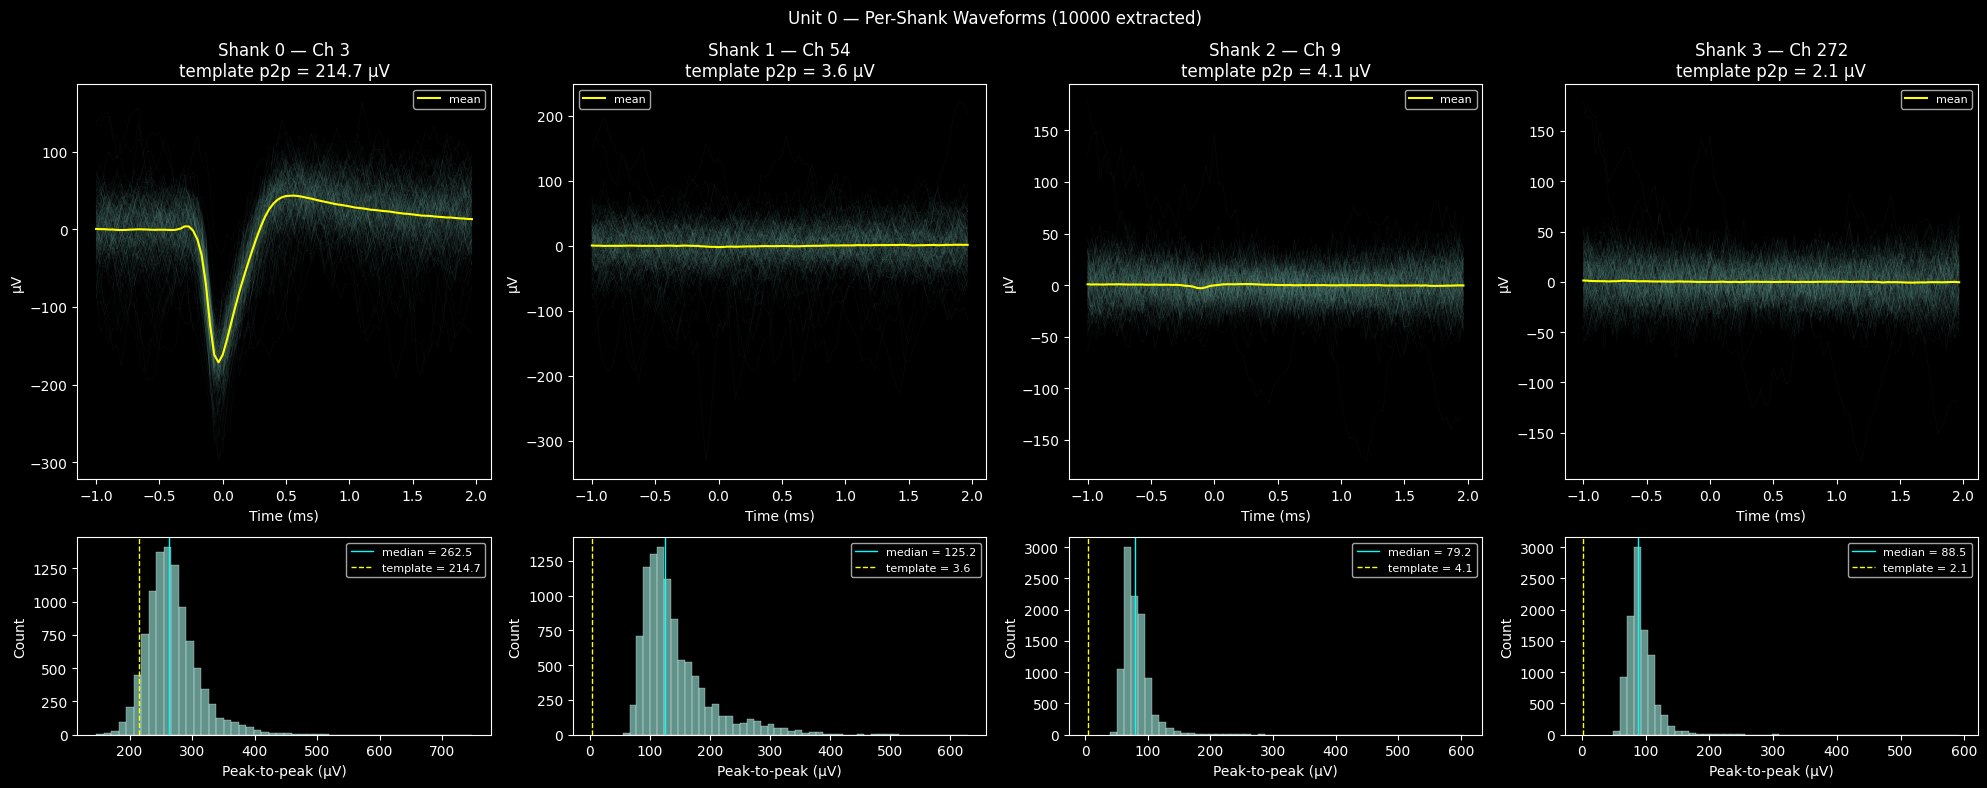

In [10]:
waveforms_ext = pp.get_extension('waveforms')

cluster_id = good_units[0]  # <-- change this to investigate different units
unit_template = template_ext.get_unit_template(cluster_id, operator='average')
unit_template = unit_template - unit_template.mean(axis=0, keepdims=True)

# Get waveforms from the sorting analyzer (up to 10k spikes, saved to disk)
waveforms = waveforms_ext.get_waveforms_one_unit(unit_id=cluster_id)
# Centre each snippet per-channel (remove baseline drift)
waveforms = waveforms - waveforms.mean(axis=1, keepdims=True)
print(f"Unit {cluster_id}: {waveforms.shape[0]} waveforms, shape {waveforms.shape}")

_ = plot_shankwise_waveforms(cluster_id, waveforms, unit_template, contacts_df,
                             ms_before, ms_after, fs=fs)